# Principal component analysis
1. load data and meta data
2. basic minimal preprocessing
3. perform PCA
4. plot PCA embeddings, variance and loadings

In [ ]:
import logging
from pathlib import PureWindowsPath
import pandas as pd

import tempfile
import alphapepttools as at
from alphapepttools.pl.figure import create_figure, label_axes
from alphapepttools.pl.plots import Plots
from alphapepttools.pl.colors import BaseColormaps


logging.basicConfig(level=logging.INFO)

## Load the data 

We download the data from [this](https://datashare.biochem.mpg.de/s/WPLspCwygBEMTa5) folder (ca. 2 megabytes)

In [ ]:
output_dir = "./datasets/data_for_04_basic_PCA_workflow"
pg_table_path = at.data.get_data("hela_pg_diann", output_dir=output_dir if output_dir else tempfile.mkdtemp())
metadata_path = at.data.get_data("hela_metadata", output_dir=output_dir if output_dir else tempfile.mkdtemp())

./datasets/data_for_04_basic_PCA_workflow/report.pg_matrix.tsv already exists (1.0532913208007812 MB)
./datasets/data_for_04_basic_PCA_workflow/simple_metadata.csv already exists (0.0013446807861328125 MB)


We can read the data easily with the `alphapepttools.io` functionalities and match the metadata to the observations

In [ ]:
# Read PG table and
# Parse full filepaths to file names (as in metadata file)
# Set uniprot ids as index
adata = at.io.read_pg_table(pg_table_path, search_engine="diann")
adata.obs_names = adata.obs_names.to_series().apply(lambda x: PureWindowsPath(str(x)).stem)
adata.var = adata.var.reset_index(names="protein_names").set_index("uniprot_ids")

# Read metadata
metadata = pd.read_csv(metadata_path, sep=",", index_col="filename")

adata = at.pp.add_metadata(adata=adata, incoming_metadata=metadata, axis=0)
adata

AnnData object with n_obs × n_vars = 18 × 4954
    obs: 'replicate', 'fraction'
    var: 'protein_names', 'genes', 'description'

## Basic EDA on a synthetic example dataset:

1. Generate example data
2. Filter for data completeness on sample level
3. Visualize samples as histograms
4. Save data

### Filter by data completeness:

Remove features which have more than the allowed fraction of missing values

In [ ]:
print("The numeric data in the anndata object:")
display(adata.to_df().head())

print("The sample-level metadata in the anndata object:")
display(adata.obs.head())

print("The feature-level metadata in the anndata object:")
display(adata.var.head())

#  filter out features with more than 25 % missing values
print("Before filtering, the shape of the anndata object: ", adata.shape)
adata = at.pp.filter_data_completeness(adata=adata, max_missing=0.25, action="drop")
print("After filtering, the shape of the anndata object: ", adata.shape)

print("The numeric data in the anndata object:")
display(adata.to_df().head())

print("The sample-level metadata in the anndata object:")
display(adata.obs.head())

print("The feature-level metadata in the anndata object:")
display(adata.var.head())

The numeric data in the anndata object:


uniprot_ids,A0A024R1R8;Q9Y2S6,A0A0B4J2F0,A0A0J9YX75;A0A0J9YXY3;P0DPF7,A0AV96,A0FGR8,A0JLT2,A0PJW6,A1L0T0,A1L390,A1X283,...,Q9Y6N5,Q9Y6N6,Q9Y6N7,Q9Y6N8,Q9Y6R0,Q9Y6V7,Q9Y6W5,Q9Y6X3,Q9Y6X9,Q9Y6Y8
20210131_EXPL4_ViAl_SA_HeLa_Evosep_21min_DIA_120k_15k_1-5_Map2_3K,9506220.0,9930580.0,NaN,6414570.0,29546900.0,NaN,19563300.0,23059400.0,1346120.0,11691800.0,...,39051400.0,172419.0,6796840.0,8998980.0,NaN,NaN,5111880.0,NaN,NaN,7060290.0
20210131_EXPL4_ViAl_SA_HeLa_Evosep_21min_DIA_120k_15k_1-5s_Map1_1K_20210131142601,25866000.0,NaN,NaN,18604800.0,18958500.0,3202770.0,NaN,14090600.0,790375.0,23128600.0,...,10291200.0,NaN,3829290.0,NaN,574729.0,19405500.0,6310680.0,10867000.0,11684000.0,13398300.0
20210131_EXPL4_ViAl_SA_HeLa_Evosep_21min_DIA_120k_15k_1-5s_Map1_3K,10150200.0,11627800.0,NaN,6550420.0,28679800.0,NaN,19387300.0,24248100.0,963907.0,9263040.0,...,38928800.0,NaN,5441930.0,9034600.0,1026870.0,NaN,3963610.0,NaN,NaN,6189950.0
20210131_EXPL4_ViAl_SA_HeLa_Evosep_21min_DIA_120k_15k_1-5s_Map1_6K,14660600.0,8741560.0,NaN,9638120.0,35471700.0,NaN,15716300.0,36269500.0,NaN,11779400.0,...,33905400.0,237138.0,5068170.0,7413300.0,965536.0,NaN,4858220.0,NaN,NaN,6046510.0
20210131_EXPL4_ViAl_SA_HeLa_Evosep_21min_DIA_120k_15k_1-5s_Map1_12K,23477900.0,1497570.0,NaN,16496400.0,27413400.0,NaN,2334540.0,24950500.0,NaN,21687600.0,...,8834620.0,187094.0,3736040.0,4581280.0,1516620.0,NaN,7919380.0,NaN,NaN,9935580.0


The sample-level metadata in the anndata object:


,replicate,fraction
20210131_EXPL4_ViAl_SA_HeLa_Evosep_21min_DIA_120k_15k_1-5_Map2_3K,Map2,3K
20210131_EXPL4_ViAl_SA_HeLa_Evosep_21min_DIA_120k_15k_1-5s_Map1_1K_20210131142601,Map1,1K
20210131_EXPL4_ViAl_SA_HeLa_Evosep_21min_DIA_120k_15k_1-5s_Map1_3K,Map1,3K
20210131_EXPL4_ViAl_SA_HeLa_Evosep_21min_DIA_120k_15k_1-5s_Map1_6K,Map1,6K
20210131_EXPL4_ViAl_SA_HeLa_Evosep_21min_DIA_120k_15k_1-5s_Map1_12K,Map1,12K


The feature-level metadata in the anndata object:


...

uniprot_ids,A0A024R1R8;Q9Y2S6,A0AV96,A0FGR8,A1L0T0,A1X283,A5PLL7,A5YKK6,A6NCE7;Q9GZQ8,A6NDG6,A6NHR9,...,Q9Y6K5,Q9Y6M0,Q9Y6M1,Q9Y6M4,Q9Y6M5,Q9Y6N7,Q9Y6N8,Q9Y6R0,Q9Y6W5,Q9Y6Y8
20210131_EXPL4_ViAl_SA_HeLa_Evosep_21min_DIA_120k_15k_1-5_Map2_3K,9506220.0,6414570.0,29546900.0,23059400.0,11691800.0,2741150.0,10835800.0,5629360.0,561137.0,3789200.0,...,8955980.0,27799800.0,3070990.0,3151630.0,64329500.0,6796840.0,8998980.0,NaN,5111880.0,7060290.0
20210131_EXPL4_ViAl_SA_HeLa_Evosep_21min_DIA_120k_15k_1-5s_Map1_1K_20210131142601,25866000.0,18604800.0,18958500.0,14090600.0,23128600.0,4624200.0,11243600.0,7728880.0,462468.0,47274600.0,...,9021290.0,18298000.0,NaN,1579620.0,38458300.0,3829290.0,NaN,574729.0,6310680.0,13398300.0
20210131_EXPL4_ViAl_SA_HeLa_Evosep_21min_DIA_120k_15k_1-5s_Map1_3K,10150200.0,6550420.0,28679800.0,24248100.0,9263040.0,3809220.0,10480100.0,7059070.0,700098.0,NaN,...,7307580.0,23668700.0,3084110.0,3130200.0,60378200.0,5441930.0,9034600.0,1026870.0,3963610.0,6189950.0
20210131_EXPL4_ViAl_SA_HeLa_Evosep_21min_DIA_120k_15k_1-5s_Map1_6K,14660600.0,9638120.0,35471700.0,36269500.0,11779400.0,5127720.0,19063600.0,8905940.0,582714.0,NaN,...,12709900.0,39207800.0,6057120.0,3672700.0,56567800.0,5068170.0,7413300.0,965536.0,4858220.0,6046510.0
20210131_EXPL4_ViAl_SA_HeLa_Evosep_21min_DIA_120k_15k_1-5s_Map1_12K,23477900.0,16496400.0,27413400.0,24950500.0,21687600.0,5740560.0,39849800.0,8597510.0,595144.0,3586450.0,...,18124000.0,30144100.0,10509100.0,3353660.0,42608500.0,3736040.0,4581280.0,1516620.0,7919380.0,9935580.0


The sample-level metadata in the anndata object:


,replicate,fraction
20210131_EXPL4_ViAl_SA_HeLa_Evosep_21min_DIA_120k_15k_1-5_Map2_3K,Map2,3K
20210131_EXPL4_ViAl_SA_HeLa_Evosep_21min_DIA_120k_15k_1-5s_Map1_1K_20210131142601,Map1,1K
20210131_EXPL4_ViAl_SA_HeLa_Evosep_21min_DIA_120k_15k_1-5s_Map1_3K,Map1,3K
20210131_EXPL4_ViAl_SA_HeLa_Evosep_21min_DIA_120k_15k_1-5s_Map1_6K,Map1,6K
20210131_EXPL4_ViAl_SA_HeLa_Evosep_21min_DIA_120k_15k_1-5s_Map1_12K,Map1,12K


The feature-level metadata in the anndata object:


,protein_names,genes,description
uniprot_ids,,,
A0A024R1R8;Q9Y2S6,TMA7B_HUMAN;TMA7_HUMAN,TMA7;TMA7B,Translation machinery-associated protein 7B
A0AV96,RBM47_HUMAN,RBM47,RNA-binding protein 47
A0FGR8,ESYT2_HUMAN,ESYT2,Extended synaptotagmin-2
A1L0T0,HACL2_HUMAN,ILVBL,2-hydroxyacyl-CoA lyase 2
A1X283,SPD2B_HUMAN,SH3PXD2B,SH3 and PX domain-containing protein 2B


## Adding QC metrics

We will add basic qc metrics: sum of sample intensity, number of detected proteins and fraction of detected ptoteins for each sample.
by running the the `at.metrics.calculate_qc_metrics(adata)` we will get an addition of columns to `obs` and `var` meta data with the following metrics:
        - ``adata.obs["total_sample_intensity"]``: Sum of intensities per observation
        - ``adata.obs["num_features_detected"]``: Number of detected features per observation
        - ``adata.obs["fraction_detected_features"]``: Fraction of detected features per observation
        - ``adata.var["total_feature_intensity"]``: Sum of intensities per feature across all observations
        - ``adata.var["num_samples_detected"]``: Number of samples in which the features was detected
        - ``adata.var["fraction_detected_samples"]``: Fraction of detected observations per feature (across all observations)


In [ ]:
# Calculate QC metrics on the raw layer (before log transformation)
at.metrics.calculate_qc_metrics(adata)

# View the added QC metrics
print("QC metrics added to adata.obs:")
display(adata.obs[["total_sample_intensity", "num_features_detected", "fraction_detected_features"]].head())
print("QC metrics added to adata.var:")
display(adata.var[["total_feature_intensity", "num_samples_detected", "fraction_detected_samples"]].head())

QC metrics added to adata.obs:


,total_sample_intensity,num_features_detected,fraction_detected_features
20210131_EXPL4_ViAl_SA_HeLa_Evosep_21min_DIA_120k_15k_1-5_Map2_3K,1.680074e+11,2737,0.966796
20210131_EXPL4_ViAl_SA_HeLa_Evosep_21min_DIA_120k_15k_1-5s_Map1_1K_20210131142601,3.310337e+11,2642,0.933239
20210131_EXPL4_ViAl_SA_HeLa_Evosep_21min_DIA_120k_15k_1-5s_Map1_3K,1.683722e+11,2715,0.959025
20210131_EXPL4_ViAl_SA_HeLa_Evosep_21min_DIA_120k_15k_1-5s_Map1_6K,1.837695e+11,2687,0.949135
20210131_EXPL4_ViAl_SA_HeLa_Evosep_21min_DIA_120k_15k_1-5s_Map1_12K,1.845585e+11,2813,0.993642


QC metrics added to adata.var:


,total_feature_intensity,num_samples_detected,fraction_detected_samples
uniprot_ids,,,
A0A024R1R8;Q9Y2S6,397339190.0,18,1.000000
A0AV96,312302780.0,18,1.000000
A0FGR8,387062340.0,18,1.000000
A1L0T0,328032940.0,16,0.888889
A1X283,432011540.0,18,1.000000


We can also plot the distributions of these values, to identify potenital ourliers

INFO:root:Column 'total_sample_intensity' found in: data.obs.columns. Using that
INFO:root:Column 'num_features_detected' found in: data.obs.columns. Using that
INFO:root:Column 'fraction_detected_features' found in: data.obs.columns. Using that


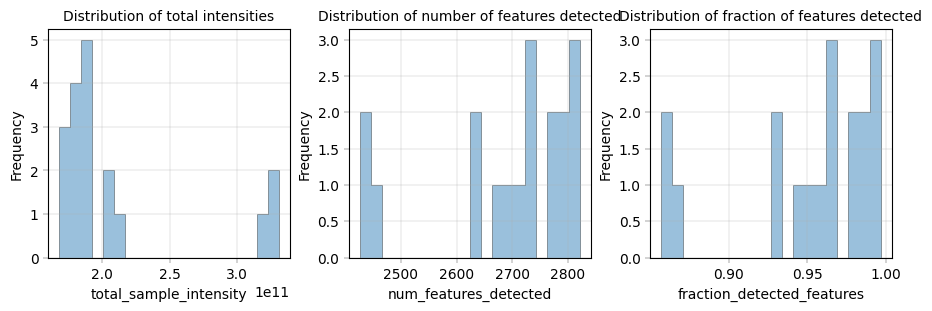

In [ ]:
# Apply the AxisManager to make axes iterable and apply consistent alphapepttools styling.
# Axes can also be accessed directly by indexing the axm object.
fig, axm = create_figure(nrows=1, ncols=3, figsize=(9, 3))

# Plot.histogram handles adata natively. Columns from the data and metadata are accessible
# Plot the distribution of sum intensities across samples
ax = axm.next()
Plots.histogram(
    data=adata,
    value_column="total_sample_intensity",
    bins=20,
    legend="auto",
    ax=ax,
    hist_kwargs={"alpha": 0.5, "histtype": "stepfilled", "linewidth": 0.5, "edgecolor": "black"},
)
label_axes(ax, "total_sample_intensity", "Frequency", "Distribution of total intensities")

# Plot the distribution of number of features detected across samples
ax = axm.next()
Plots.histogram(
    data=adata,
    value_column="num_features_detected",
    bins=20,
    legend="auto",
    ax=ax,
    hist_kwargs={"alpha": 0.5, "histtype": "stepfilled", "linewidth": 0.5, "edgecolor": "black"},
)
label_axes(ax, "num_features_detected", "Frequency", "Distribution of number of features detected")

# Plot the distribution of fraction of features identified across samples
ax = axm.next()
Plots.histogram(
    data=adata,
    value_column="fraction_detected_features",
    bins=20,
    legend="auto",
    ax=ax,
    hist_kwargs={"alpha": 0.5, "histtype": "stepfilled", "linewidth": 0.5, "edgecolor": "black"},
)
label_axes(ax, "fraction_detected_features", "Frequency", "Distribution of fraction of features detected")

## Creating new layers prior to preprocessing

This way, we can save the raw data and try different pp steps on the raw data.

In [ ]:
# save the raw data before log transformation
adata.layers["raw"] = adata.X.copy()

# log2 transform the data
at.pp.nanlog(adata, base=2)

### Visualize the distribution of values in different levels of an observational metadata variable

In this example, check the distribution of "gene_1" expression values per cell type.

INFO:root:Column 'A1L0T0' found in: data.var_names. Using that
INFO:root:Column 'A1L0T0' found in: data.var_names. Using that
INFO:root:Column 'replicate' found in: data.obs.columns. Using that


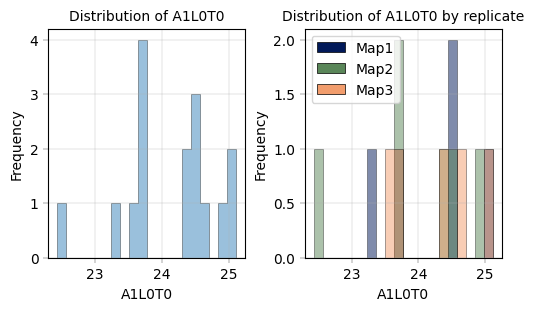

In [ ]:
# Same here, we make axes iterable and apply consistent alphapepttools styling using AxisManager.
fig, axm = create_figure(nrows=1, ncols=2, figsize=(5, 3))

# Focus on the distribution of protein A1L0T0
ax = axm.next()
Plots.histogram(
    data=adata,
    value_column="A1L0T0",
    bins=20,
    legend="auto",
    ax=ax,
    hist_kwargs={"alpha": 0.5, "histtype": "stepfilled", "linewidth": 0.5, "edgecolor": "black"},
)
label_axes(ax, "A1L0T0", "Frequency", "Distribution of A1L0T0")

# Focus on the distribution of protein A1L0T0 in the different replicates
ax = axm.next()
Plots.histogram(
    data=adata,
    value_column="A1L0T0",
    color_map_column="replicate",
    bins=20,
    legend="auto",
    ax=ax,
    hist_kwargs={"alpha": 0.5, "histtype": "stepfilled", "linewidth": 0.5, "edgecolor": "black"},
)
label_axes(ax, "A1L0T0", "Frequency", "Distribution of A1L0T0 by replicate")

# # save figure
# save_figure(
#     fig=fig,
#     filename="sample_histogram.png",
#     output_dir=output_directory,
#     dpi=300,
#     transparent=False,
# )

### Running PCA

Before running any PCA, we need to scale and center the data. for PCA, we also need to filter out NaN values. PCA can not be computed on matrices with missing values. Therefore, prior to PCA, we will create a list of 'core proteins' of proteins detected in all observations, save it in the feature meta data frame (adata.var)

In [ ]:
# scaling and centering the data using robust scaling (median and IQR)
adata.layers["log2"] = adata.X.copy()  # save log2 transformed data in a separate layer
at.pp.scale_and_center(adata, scaler="robust")

# add a new column to the adata.var object with the name "is_core" to indicate whether the feature is part of the core proteome
adata = at.pp.filter_data_completeness(adata, max_missing=0, action="flag", var_colname="is_core")

# view hoe many features are part of the core proteome
print("The number of features in the core proteome:")
print(adata.var["is_core"].value_counts())

INFO:root:pp.scale_and_center(): Scaling data with robust scaler.
INFO:root:pp.filter_data_completeness(): flag 1025 / 2831 features with >0.00 missing in any group.


The number of features in the core proteome:
is_core
True     1806
False    1025
Name: count, dtype: int64


Now we can run PCA, specifying the adata.var column that filters the proteins by 100% completeness:

In [ ]:
# this function is now implemented on sample level (PCA of the observations).
at.tl.pca(adata, meta_data_mask_column_name="is_core", n_comps=10)

# view the PCA results
print("The dimensions of PC coordinates in the adata.obsm are (n_obs x n_comp):")
print(adata.obsm["X_pca_obs"].shape)
print("The PCA loadings in the adata.varm are (n_var x n_comp):")
print(adata.varm["PCs_pca_obs"].shape)
print("Ratio of explained variance (n_comp):")
print(adata.uns["variance_pca_obs"]["variance_ratio"])
print("The explained variance (n_comp):")
print(adata.uns["variance_pca_obs"]["variance"])

INFO:alphapepttools.tl.embeddings:computing PCA


The dimensions of PC coordinates in the adata.obsm are (n_obs x n_comp):
(18, 10)
The PCA loadings in the adata.varm are (n_var x n_comp):
(2831, 10)
Ratio of explained variance (n_comp):
[0.51010065 0.33112813 0.05752785 0.04318519 0.01037467 0.00866608
 0.00678247 0.00552636 0.00451601 0.00421113]
The explained variance (n_comp):
[772.84657874 501.6877331   87.15966942  65.42929075  15.71852191
  13.12985601  10.27603301   8.37290701   6.84214504   6.38022703]


In addition to running PCA to get a dimentional reduction of the observations (samples), we can also perform PCA on the features (proteins). 

In [ ]:
# Now run PCA on the protein space to get their projection in the PCA space.
at.tl.pca(adata, meta_data_mask_column_name="is_core", n_comps=10, dim_space="var")

# view the PCA results for features
print("----- PCA ON FEATURES -----")
print("The dimensions of PC coordinates in the adata.varm are (n_obs x n_comp):")
print(adata.varm["X_pca_var"].shape)
print("The PCA loadings of the samples in the adata.obsm are (n_var x n_comp):")
print(adata.obsm["PCs_pca_var"].shape)
print("Ratio of explained variance (n_comp):")
print(adata.uns["variance_pca_var"]["variance_ratio"])
print("The explained variance (n_comp):")
print(adata.uns["variance_pca_var"]["variance"])

INFO:alphapepttools.tl.embeddings:computing PCA


----- PCA ON FEATURES -----
The dimensions of PC coordinates in the adata.varm are (n_obs x n_comp):
(2831, 10)
The PCA loadings of the samples in the adata.obsm are (n_var x n_comp):
(18, 10)
Ratio of explained variance (n_comp):
[0.49809658 0.33203976 0.04701231 0.04302217 0.02119409 0.01038273
 0.00875205 0.00684418 0.00555809 0.00460545]
The explained variance (n_comp):
[6.96171017 4.6407959  0.65707358 0.60130483 0.29622185 0.14511554
 0.12232418 0.09565856 0.07768336 0.06436864]


### Plot PCA results 
We can plot the PCA results on a 2D projection, look at the explained var in each PC using the scree plot, and plot the loadings od the PCs, either per PC or a scatter of 2 PCs, to understand their 'drivers'. 

INFO:root:Column 'replicate' found in: data.obs.columns. Using that
INFO:root:Column 'replicate' found in: data.obs.columns. Using that
INFO:root:Column 'pc_1' found in: data.var_names. Using that
INFO:root:Column 'pc_2' found in: data.var_names. Using that


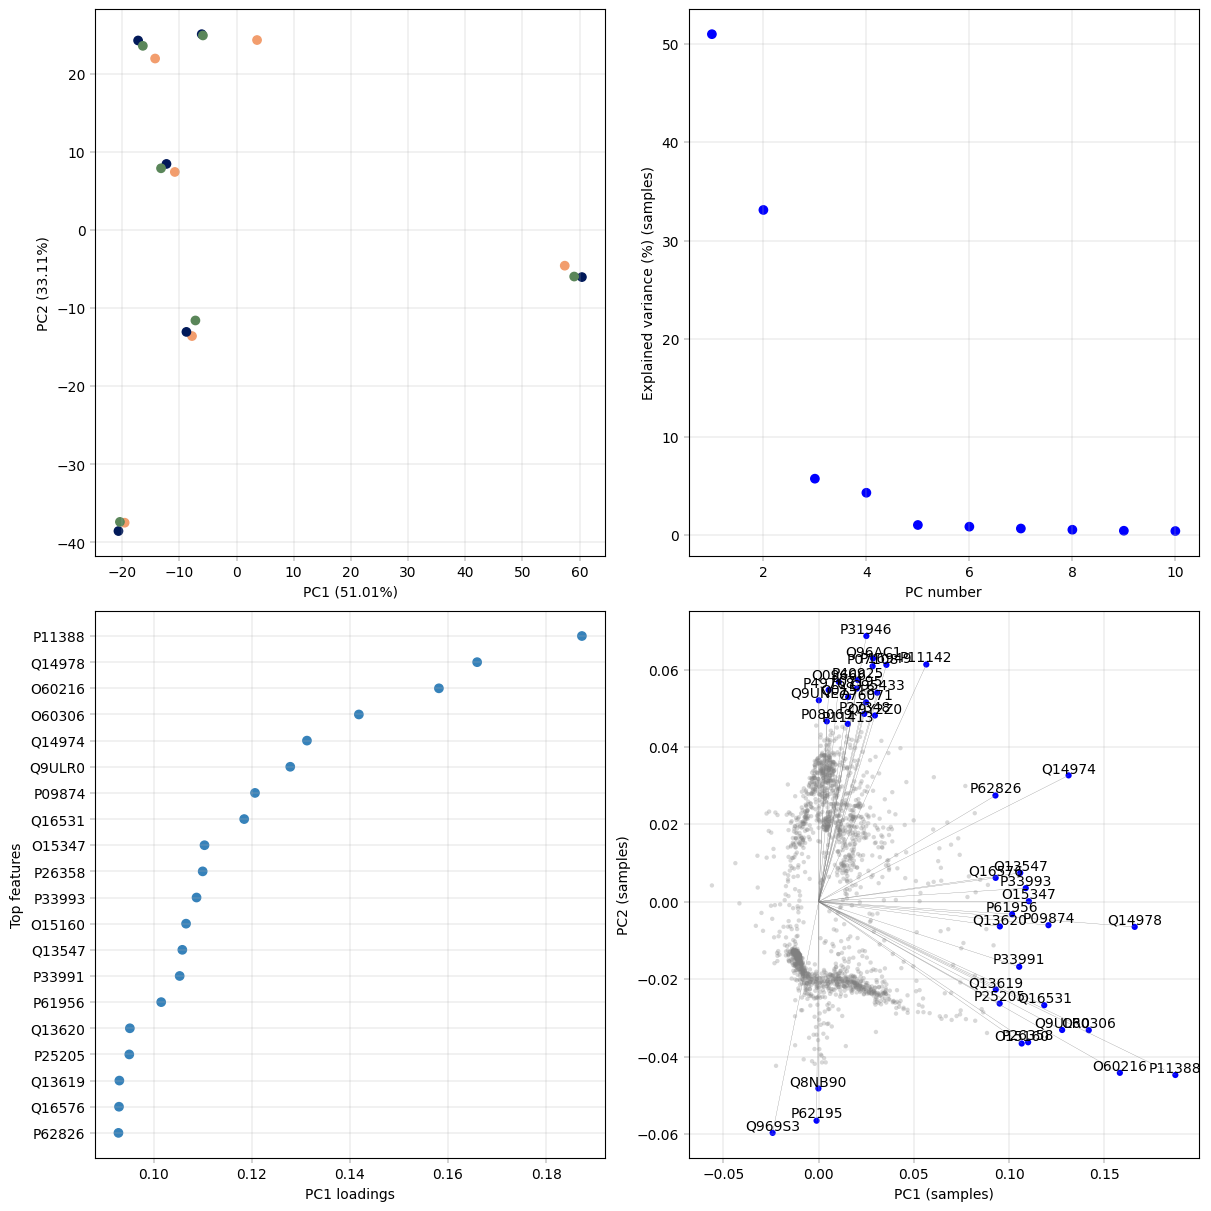

In [ ]:
fig, axm = create_figure(2, 2, figsize=(12, 12))

ax = axm.next()
# PCA plot colored by replicate
Plots.plot_pca(
    data=adata,
    ax=ax,
    x_column=1,
    y_column=2,
    label=False,
    label_column=None,
    embeddings_name=None,
    color_map_column="replicate",
)

# scree plot to show the explained variance by each PC
ax = axm.next()
Plots.scree_plot(adata=adata, ax=ax, n_pcs=50)

# top loadings of the first PC
ax = axm.next()
Plots.plot_pca_loadings(
    data=adata,
    ax=ax,
    dim=1,
    nfeatures=20,
)

# 2d loading plot with highlighted top 20 loadings
ax = axm.next()
Plots.plot_pca_loadings_2d(
    data=adata,
    ax=ax,
    pc_x=1,
    pc_y=2,
    nfeatures=20,
    add_labels=True,
    add_lines=True,
    scatter_kwargs=None,
)

We can also color the samples on the PCA based on their level of expression of specific proteins. 

INFO:root:Column 'Q07021' found in: data.obs.columns. Using that
INFO:root:Column 'pc_1' found in: data.var_names. Using that
INFO:root:Column 'pc_2' found in: data.var_names. Using that


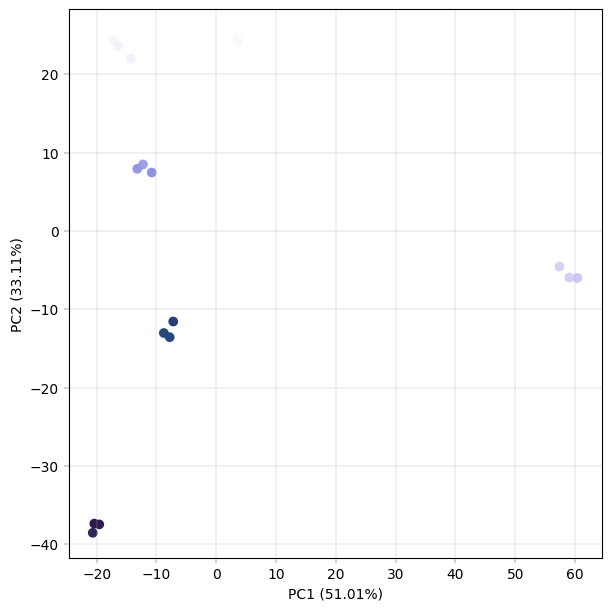

In [ ]:
fig, axm = create_figure(1, 1, figsize=(6, 6))

ax = axm.next()
prot = "Q07021"
Plots.plot_pca(
    data=adata,
    ax=ax,
    x_column=1,
    y_column=2,
    label=False,
    label_column=None,
    embeddings_name=None,
    color_map_column=prot,
    palette=BaseColormaps.get("sequential"),
)

### Plot PCA results for feature PCA 
Just like the PCA on the samples, we can plot the same plots for the results of PCA calculated on the features.  

INFO:root:Column 'pc_1' found in: data.var_names. Using that
INFO:root:Column 'pc_2' found in: data.var_names. Using that


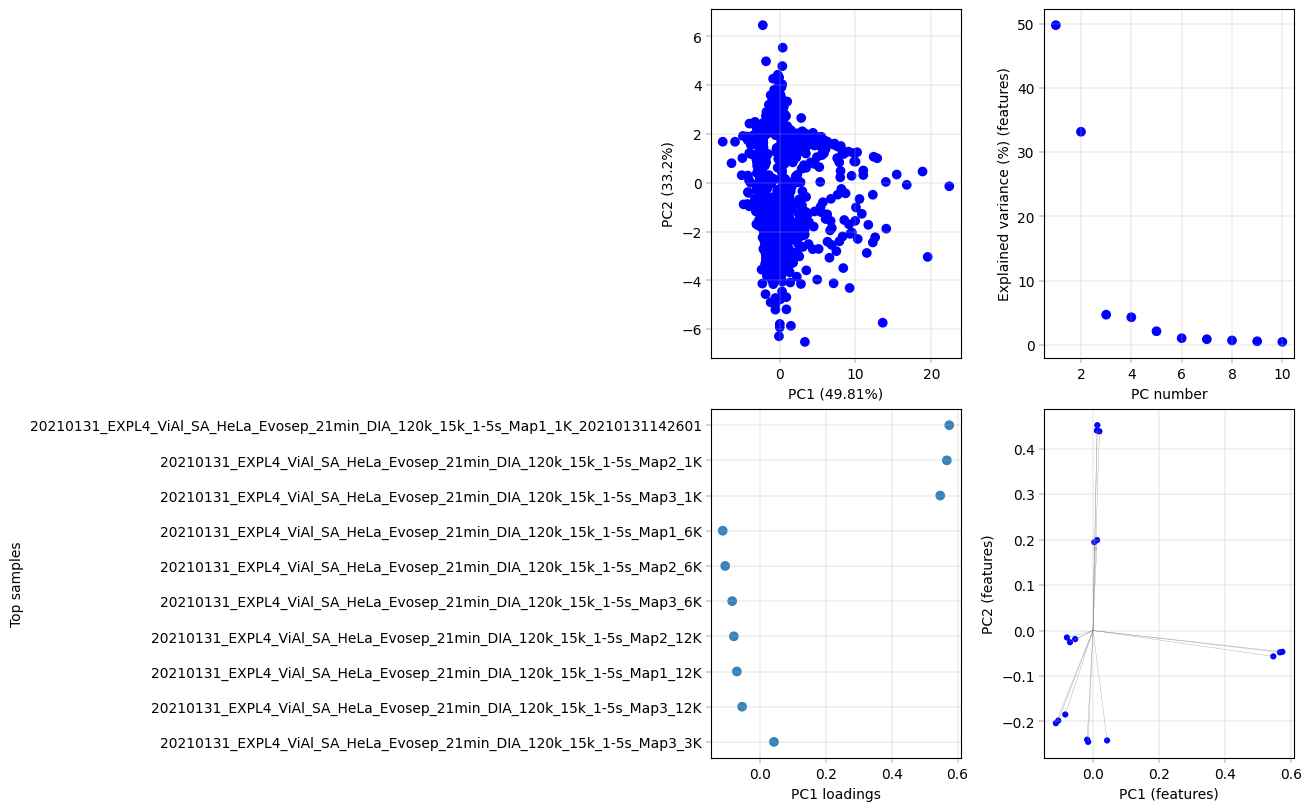

In [ ]:
# now produce the PCAs plot for the features
fig, axm = create_figure(2, 2, figsize=(13, 8))

ax = axm.next()
Plots.plot_pca(
    data=adata,
    ax=ax,
    x_column=1,
    y_column=2,
    dim_space="var",
    label=False,
    label_column=None,
    embeddings_name=None,
)

ax = axm.next()
Plots.scree_plot(adata=adata, ax=ax, n_pcs=50, dim_space="var")

ax = axm.next()
Plots.plot_pca_loadings(data=adata, ax=ax, dim=1, nfeatures=10, dim_space="var")

ax = axm.next()
Plots.plot_pca_loadings_2d(
    data=adata,
    ax=ax,
    pc_x=1,
    pc_y=2,
    nfeatures=10,
    add_labels=False,
    add_lines=True,
    scatter_kwargs=None,
    dim_space="var",
)

### UMAP Visualization with Scanpy

To explore and visualize the high-dimensional proteomics data, we use **UMAP (Uniform Manifold Approximation and Projection)** as implemented in **Scanpy**. UMAP projects complex, high-dimensional feature spaces into a lower-dimensional space (typically 2D) while preserving the local and global structure of the data. This allows us to identify clusters, relationships, and potential outliers in the proteomic profiles at a glance.

In this notebook, Scanpy’s `sc.pp.neighbors()` and `sc.tl.umap()` functions are applied to the processed data matrix to compute a nearest-neighbor graph and then generate UMAP coordinates. We will use the sample PCA matrix for neighbor calculations. The resulting UMAP embedding provides an intuitive visualization of sample similarity and grouping based on proteomic features, complementing downstream analyses such as clustering or differential expression.


In [ ]:
import scanpy as sc

sc.pp.neighbors(adata, n_neighbors=10, use_rep="X_pca_obs")  # use the PCA results on samples
sc.tl.umap(adata)

  from .autonotebook import tqdm as notebook_tqdm



In [ ]:
# location of the umap coordinates in the adata.obsm
print("The UMAP coordinates in the adata.obsm are in adata.obsm['X_umap'] with shape: ", adata.obsm["X_umap"].shape)
print(adata.obsm["X_umap"])

The UMAP coordinates in the adata.obsm are in adata.obsm['X_umap'] with shape:  (18, 2)
[[32.945724   3.5636468]
 [32.70608    2.546359 ]
 [33.76123    3.294497 ]
 [33.463757   4.0534253]
 [32.579155   5.059523 ]
 [34.511883   3.8603823]
 [33.383286   5.895426 ]
 [33.348415   2.2564232]
 [34.366386   4.6480603]
 [33.46207    4.904082 ]
 [31.566055   4.764385 ]
 [32.398273   6.048396 ]
 [34.477673   2.533692 ]
 [31.956352   3.572896 ]
 [34.22026    5.633101 ]
 [35.424217   3.6034298]
 [35.146736   5.200197 ]
 [33.415512   6.6993117]]


### Plot UMAP
We can either plot the UMAP results using scanpy's plotting function, or we can use alphapepttools plotting function, with adding the umap coordinates directly to the obs df.


... storing 'replicate' as categorical
... storing 'fraction' as categorical
... storing 'genes' as categorical
... storing 'description' as categorical


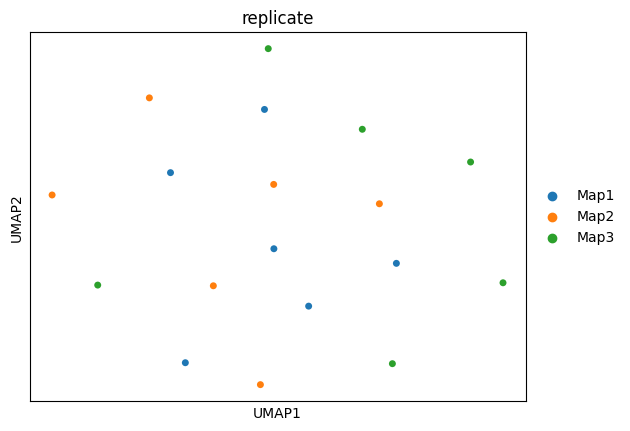

In [ ]:
# scanpy's plotting function
sc.pl.umap(adata, color="replicate", size=100)  # the size is usually much smaller

Another option is to copy the coordinates into the `adata.obs` data frame, to plot in using `scatter` function in `alphapepttools` package

INFO:root:Column 'replicate' found in: data.obs.columns. Using that
INFO:root:Column 'replicate' found in: data.obs.columns. Using that
INFO:root:Column 'UMAP1' found in: data.obs.columns. Using that
INFO:root:Column 'UMAP2' found in: data.obs.columns. Using that


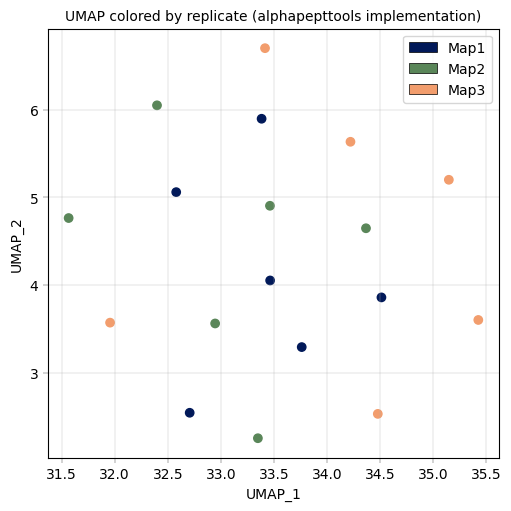

In [ ]:
adata.obs["UMAP1"] = adata.obsm["X_umap"][:, 0]
adata.obs["UMAP2"] = adata.obsm["X_umap"][:, 1]

fig, axm = create_figure(1, 1, figsize=(5, 5))
ax = axm.next()
Plots.scatter(adata, x_column="UMAP1", y_column="UMAP2", color_map_column="replicate", ax=ax, legend="auto")

label_axes(
    ax=ax,
    xlabel="UMAP_1",
    ylabel="UMAP_2",
    title="UMAP colored by replicate (alphapepttools implementation)",
)

## Bayesian PCA (BPCA)

Unlike standard PCA, **Bayesian PCA (BPCA)** can handle missing values directly without requiring complete cases or imputation. This makes it particularly useful for proteomics data where missing values are common.

BPCA assumes additive Gaussian noise and iteratively estimates the latent structure. For complete data, BPCA converges to the standard PCA solution.

In [ ]:
# Run BPCA on observations (samples)
# Unlike PCA, BPCA can handle missing values, so we don't need to filter for core proteome
at.tl.bpca(adata, n_comps=8)

# View the BPCA results
print("The dimensions of BPCA coordinates in the adata.obsm are (n_obs x n_comp):")
print(adata.obsm["X_bpca_obs"].shape)
print("The BPCA loadings in the adata.varm are (n_var x n_comp):")
print(adata.varm["PCs_bpca_obs"].shape)
print("Ratio of explained variance (n_comp):")
print(adata.uns["variance_bpca_obs"]["variance_ratio"])

The dimensions of BPCA coordinates in the adata.obsm are (n_obs x n_comp):
(18, 8)
The BPCA loadings in the adata.varm are (n_var x n_comp):
(2831, 8)
Ratio of explained variance (n_comp):
[0.48727885 0.31788086 0.05994942 0.05286345 0.         0.
 0.         0.        ]


Plotting BPCA results is done using the same functions for PCA plotting, either with the addition of `method = "bpca"` if using default naming or by specifying the `embedding_name` in the arguments if default name setting was not used in `run_bpca` function. 

INFO:root:Column 'replicate' found in: data.obs.columns. Using that
INFO:root:Column 'replicate' found in: data.obs.columns. Using that
INFO:root:Column 'pc_1' found in: data.var_names. Using that
INFO:root:Column 'pc_2' found in: data.var_names. Using that


Text(0.5, 1.0, 'BPCA 2D Loadings')

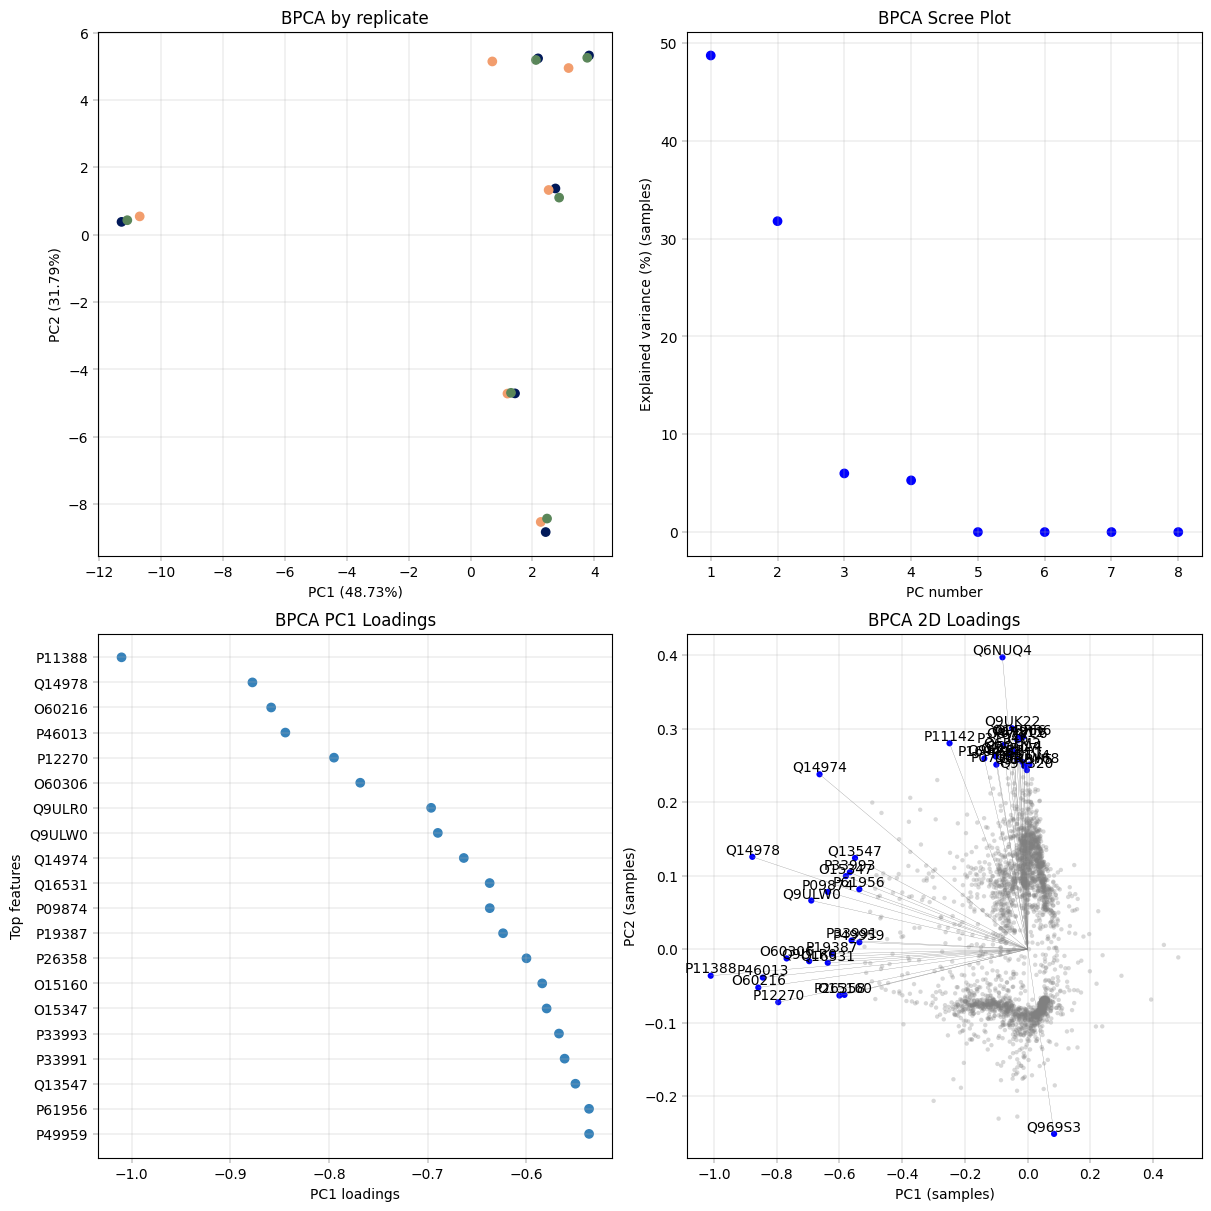

In [ ]:
# Plot BPCA results
fig, axm = create_figure(2, 2, figsize=(12, 12))

ax = axm.next()
# BPCA plot colored by replicate
Plots.plot_pca(
    data=adata,
    ax=ax,
    x_column=1,
    y_column=2,
    label=False,
    label_column=None,
    method="bpca",
    color_map_column="replicate",
)
ax.set_title("BPCA by replicate")

# scree plot for BPCA
ax = axm.next()
Plots.scree_plot(adata=adata, ax=ax, n_pcs=10, method="bpca")
ax.set_title("BPCA Scree Plot")

# top loadings of the first BPCA component
ax = axm.next()
Plots.plot_pca_loadings(data=adata, ax=ax, dim=1, nfeatures=20, method="bpca")
ax.set_title("BPCA PC1 Loadings")

# 2d loading plot for BPCA
ax = axm.next()
Plots.plot_pca_loadings_2d(
    data=adata, ax=ax, pc_x=1, pc_y=2, nfeatures=20, add_labels=True, add_lines=True, method="bpca"
)
ax.set_title("BPCA 2D Loadings")